In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

In [3]:
print("PyTorch version:", torch.__version__)

PyTorch version: 2.13.0+cpu


In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [5]:
train_df = pd.read_csv("../data/long_basic/train.csv")
val_df = pd.read_csv("../data/long_basic/validation.csv")
test_df = pd.read_csv("../data/long_basic/test.csv")

In [6]:
categorical_cols = [
    "league",
    "position_group"
]

numeric_cols = [
    "age",
    "starts",
    "minutes",
    "goals",
    "assists",
    "non_penalty_goals",
    "penalty_goals",
    "penalty_attempts",
    "goals_per90",
    "assists_per90",
    "goal_contrib_per90"
]

feature_cols = categorical_cols + numeric_cols

In [7]:
X_train = train_df[feature_cols]
y_train = train_df["next_goals"]

X_val = val_df[feature_cols]
y_val = val_df["next_goals"]

X_test = test_df[feature_cols]
y_test = test_df["next_goals"]

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

In [9]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [10]:
print(X_train_processed.shape)
print(X_val_processed.shape)
print(X_test_processed.shape)

(22430, 18)
(923, 18)
(926, 18)


In [14]:
X_train_tensor = torch.tensor(
    X_train_processed,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_processed,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_processed,
    dtype=torch.float32
)

In [12]:
y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
)

In [16]:
y_train_tensor = y_train_tensor.reshape(-1, 1)
y_val_tensor = y_val_tensor.reshape(-1, 1)
y_test_tensor = y_test_tensor.reshape(-1, 1)

In [17]:
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("X_val:", X_val_tensor.shape)
print("y_val:", y_val_tensor.shape)

print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

X_train: torch.Size([22430, 18])
y_train: torch.Size([22430, 1])
X_val: torch.Size([923, 18])
y_val: torch.Size([923, 1])
X_test: torch.Size([926, 18])
y_test: torch.Size([926, 1])


In [18]:
print(type(X_train_tensor))
print(X_train_tensor.dtype)
print(X_train_tensor.shape)
print(y_train_tensor.shape)

<class 'torch.Tensor'>
torch.float32
torch.Size([22430, 18])
torch.Size([22430, 1])


In [19]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [20]:
print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 22430
Validation dataset: 923
Test dataset: 926


In [22]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle = False
)

In [23]:
X_batch, y_batch = next(iter(train_loader))

print("X batch:", X_batch.shape)
print("y batch:", y_batch.shape)

X batch: torch.Size([64, 18])
y batch: torch.Size([64, 1])


In [24]:
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 351
Validation batches: 15
Test batches: 15


In [28]:
class MLPRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [30]:
input_dim = X_train_tensor.shape[1]

model = MLPRegression(input_dim)

model = model.to(device)

print(model)

MLPRegression(
  (fc1): Linear(in_features=18, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)


In [31]:
X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)

pred = model(X_batch)

print("Input:", X_batch.shape)
print("Prediction:", pred.shape)

Input: torch.Size([64, 18])
Prediction: torch.Size([64, 1])


In [32]:
print(pred[:5])

tensor([[ 0.0257],
        [-0.0090],
        [-0.0022],
        [ 0.2565],
        [-0.0063]], grad_fn=<SliceBackward0>)


In [33]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [35]:
X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

criterion = nn.MSELoss()

pred = model(X_batch)

loss = criterion(pred, y_batch)

print("Prediction shape:", pred.shape)
print("Target shape:", y_batch.shape)
print("Loss:", loss.item())

Prediction shape: torch.Size([64, 1])
Target shape: torch.Size([64, 1])
Loss: 19.661802291870117


In [36]:
# 학습 전 fc1 weight 일부 복사
before_weight = model.fc1.weight[0, :5].detach().clone()

# gradient 초기화
optimizer.zero_grad()

# 역전파
loss.backward()

# weight 업데이트
optimizer.step()

# 학습 후 weight 확인
after_weight = model.fc1.weight[0, :5].detach().clone()

print("Before:", before_weight)
print("After :", after_weight)

Before: tensor([-0.0810,  0.0551,  0.1102,  0.0566,  0.1762])
After : tensor([-0.0800,  0.0561,  0.1112,  0.0576,  0.1772])


In [41]:
model.train()

train_loss = 0.0

for X_batch, y_batch in train_loader:
    X_batch = X_batch.to(device)
    y_batch = y_batch.to(device)

    # 1. 예측
    pred = model(X_batch)

    # 2. Loss 계산
    loss = criterion(pred, y_batch)

    # 3. 이전 gradient 초기화
    optimizer.zero_grad()

    # 4. 역전파
    loss.backward()

    # 5. weight 업데이트
    optimizer.step()

    # 배치 loss 누적
    train_loss += loss.item()

train_loss /= len(train_loader)
print("Train Loss:", train_loss)

Train Loss: 11.011929581307957


In [42]:
model.eval()

val_loss = 0.0

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        pred = model(X_batch)

        loss = criterion(pred, y_batch)

        val_loss += loss.item()

val_loss /= len(val_loader)

print("Validation Loss:", val_loss)

Validation Loss: 12.778868103027344


In [43]:
model = MLPRegression(input_dim).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [44]:
epochs = 50

train_losses = []
val_losses = []

for epoch in range(epochs):

    # =========================
    # Train
    # =========================
    model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        pred = model(X_batch)
        loss = criterion(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # =========================
    # Validation
    # =========================
    model.eval()

    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)


    # 기록
    train_losses.append(train_loss)
    val_losses.append(val_loss)


    # 출력
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/50] Train Loss: 13.0857 Val Loss: 12.6624
Epoch [2/50] Train Loss: 11.1552 Val Loss: 12.7341
Epoch [3/50] Train Loss: 11.0888 Val Loss: 12.6910
Epoch [4/50] Train Loss: 11.0913 Val Loss: 12.6538
Epoch [5/50] Train Loss: 11.0387 Val Loss: 12.4116
Epoch [6/50] Train Loss: 11.0198 Val Loss: 12.4591
Epoch [7/50] Train Loss: 11.0243 Val Loss: 12.4340
Epoch [8/50] Train Loss: 10.9572 Val Loss: 12.5996
Epoch [9/50] Train Loss: 10.9336 Val Loss: 12.4979
Epoch [10/50] Train Loss: 10.9487 Val Loss: 12.5273
Epoch [11/50] Train Loss: 10.9277 Val Loss: 12.3449
Epoch [12/50] Train Loss: 10.9282 Val Loss: 12.3814
Epoch [13/50] Train Loss: 10.9169 Val Loss: 12.4383
Epoch [14/50] Train Loss: 10.9368 Val Loss: 12.4075
Epoch [15/50] Train Loss: 10.9316 Val Loss: 12.3807
Epoch [16/50] Train Loss: 10.9092 Val Loss: 12.3971
Epoch [17/50] Train Loss: 10.8794 Val Loss: 12.4956
Epoch [18/50] Train Loss: 10.8634 Val Loss: 12.6101
Epoch [19/50] Train Loss: 10.8957 Val Loss: 12.3481
Epoch [20/50] Train L

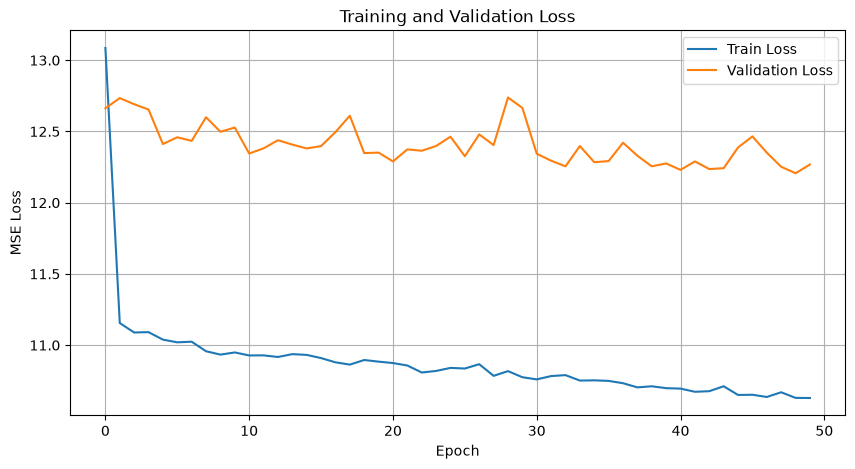

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [46]:
best_epoch = np.argmin(val_losses) + 1
best_val_loss = min(val_losses)

print("Best Epoch:", best_epoch)
print("Best Validation Loss:", best_val_loss)

Best Epoch: 49
Best Validation Loss: 12.206493091583251


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()

val_preds = []
val_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        pred = model(X_batch)

        val_preds.extend(pred.cpu().numpy().flatten())
        val_targets.extend(y_batch.cpu().numpy().flatten())

In [48]:
val_mae = mean_absolute_error(
    val_targets,
    val_preds
)

val_rmse = mean_squared_error(
    val_targets,
    val_preds
) ** 0.5

val_r2 = r2_score(
    val_targets,
    val_preds
)

print(f"Validation MAE : {val_mae:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Validation R²  : {val_r2:.4f}")

Validation MAE : 2.3890
Validation RMSE: 3.4860
Validation R²  : 0.4183


MAE
→ 평균적으로 몇 골 정도 틀리는가

RMSE
→ 큰 오차에 더 민감한 오차 크기

R²
→ 실제 next_goals의 변동을 모델이 얼마나 설명하는가

In [49]:
baseline_pred = np.full(
    len(y_val),
    y_train.mean()
)

baseline_mae = mean_absolute_error(
    y_val,
    baseline_pred
)

baseline_rmse = mean_squared_error(
    y_val,
    baseline_pred
) ** 0.5

baseline_r2 = r2_score(
    y_val,
    baseline_pred
)

print(f"Baseline MAE : {baseline_mae:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline R²  : {baseline_r2:.4f}")

Baseline MAE : 3.1736
Baseline RMSE: 4.5759
Baseline R²  : -0.0023


### Baseline MLP Validation 결과

- MAE: 2.389
- RMSE: 3.486
- R²: 0.418

단순 평균 예측 Baseline과 비교하면:

- Baseline MAE: 3.174
- Baseline RMSE: 4.576
- Baseline R²: -0.002

따라서 현재 시즌의 선수 기록을 사용한 MLP 모델이
단순 평균 예측보다 다음 시즌 득점을 유의미하게 더 잘 예측했다.

특히 MAE 기준으로 평균 예측 대비 약 0.78골의 오차 감소가 확인되었다.

다만 Validation R²가 약 0.42 수준이므로,
현재 long_basic 피처만으로 다음 시즌 득점의 모든 변동을 설명하기는 어렵다.